# Sanger Sequencing for IPDblock/cowboy colonies
- ensure all items sent for sequencing are from single colonies after streaking out from a plate and that you have seperate well labled glycerol stocks for each colony
- if that is not true, your sequencing item may be polyclonal and therefore have a mix of DNA, making your sequencing data inaccurate
- basic protocol is here https://wiki.ipd.uw.edu/protocols/wet_lab/cowboy_biochemistry#getting_publication_quality_data
- for questions about the script or good wetlab practices contact Stacey, though if they've already left for Denmark just ask someone else

In [2]:
# THIS IS THE GUTS OF THE SCRIPT
# Don't change these unless you know what you're doing
# If you don't know what you're doing you can just hide this by clicking the bar on the left side so long as you have actually run this block

from Bio import SeqIO, Align
from Bio.Align import PairwiseAligner, substitution_matrices
from collections import defaultdict
import matplotlib.pyplot as plt
import glob
import pandas as pd

def reverse_complement(seq):
    complement = {'A':'T','T':'A','C':'G','G':'C','N':'N'}
    return ''.join(complement[x] for x in reversed(seq.upper()))

def read_abi_files(map_df, sequence_folder, seq_folder_in_file):
    records = []
    for i,r in map_df.iterrows():
        if seq_folder_in_file:
            file = r.filename
        else:
            file = sequence_folder + r.filename
        records.append(SeqIO.read(file, "abi"))
    map_df['records'] = records
    return map_df

def make_aligner():
    aligner = PairwiseAligner()
    aligner.mode = 'local' 
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -5
    aligner.extend_gap_score = -1
    
    #load and modify matrix so aligning N to anything is 0
    matrix = substitution_matrices.load("NUC.4.4")
    alphabet = "ACGTN"
    for a in alphabet:
        for b in alphabet:
            if a == "N" or b == "N":
                matrix[a, b] = 0   # make it better to align N than mismatch, but worse than match
    aligner.substitution_matrix = matrix
    return aligner

def align_orfs(orf, seq,aligner):
    align =aligner.align(orf.upper(), seq.upper())
    return align[0]

def align_to_orf(map_df, order_df):
    orfs = [key for key in order_df.columns if 'ORF' in key]
    all_alignments = []
    aligner = make_aligner()
    for i, r in map_df.iterrows():
        well = r.position
        orf = order_df[orfs[0]][well].upper()
        if 'f' in r.direction: seq = str(r['records'].seq).upper()
        else: seq = reverse_complement(str(r['records'].seq)).upper()
        alignments = align_orfs(orf,seq,aligner)
        all_alignments.append(alignments)
    map_df['alignments'] = all_alignments
    return map_df

def print_low_qual_alignments(map_df):
    print(f"WELL\tCOLONY\tQUALITY")
    q_list = []
    for i,r in map_df.iterrows():
        alignment = r.alignments
        seq1, seq2 = alignment.sequences
        coords = alignment.coordinates
        matches = 0
        total = 0
        for i in range(coords.shape[1] - 1):
            s1, e1 = coords[0, i], coords[0, i+1]
            s2, e2 = coords[1, i], coords[1, i+1]

            if (e1 - s1) > 0 and (e2 - s2) > 0:
                for j in range(e1 - s1):
                    if seq1[s1 + j] == seq2[s2 + j]:
                        matches += 1
                    total += 1
        quality = matches / total if total > 0 else 0
        q_list.append(quality)
        print(f"{r.position}\t{r.colony_num}\t{quality*100}%")
        if quality <.95:
            print(r.alignments)
    map_df['quality'] = q_list
    return map_df

def get_differences(map_df):
    all_mismatches = []
    all_insertions = []  # in seq2 relative to seq1
    all_deletions = []   # in seq2 relative to seq1
    for idx, r in map_df.iterrows():
        alignment = r.alignments
        seq1, seq2 = alignment.sequences
        coords = alignment.coordinates

        mismatches = []
        insertions = []  # in seq2 relative to seq1
        deletions = []   # in seq2 relative to seq1

        for i in range(coords.shape[1] - 1):
            s1, e1 = coords[0, i], coords[0, i+1]
            s2, e2 = coords[1, i], coords[1, i+1]

            len1 = e1 - s1
            len2 = e2 - s2

            if len1 > 0 and len2 > 0:
                # aligned block → check mismatches
                for j in range(len1):
                    if seq1[s1 + j] != seq2[s2 + j]:
                        mismatches.append({
                            "pos_seq1": int(s1 + j),
                            "pos_seq2": int(s2 + j),
                            "base_seq1": seq1[s1 + j],
                            "base_seq2": seq2[s2 + j],
                        })

            elif len1 > 0:
                # deletion in seq2 (gap in seq2)
                deletions.append({
                    "seq1_range": (int(s1), int(e1)),
                    "seq2_pos": int(s2)
                })

            elif len2 > 0:
                # insertion in seq2 (gap in seq1)
                insertions.append({
                    "seq2_range": (int(s2), int(e2)),
                    "seq1_pos": int(s1)
                })
        all_mismatches.append(mismatches)
        all_insertions.append(insertions)
        all_deletions.append(deletions)
    map_df['mismatches'] = all_mismatches
    map_df['insertions'] = all_insertions
    map_df['deletions'] = all_deletions
    return map_df


def annotate_base_and_get_bad_pos(r):
    bad_pos = []
    bases_seq = [f'{i} {base}' for i,base in enumerate(str(r.records.seq))]
    for mis in r.mismatches: 
        bad_pos.append(mis['pos_seq2'])
        bases_seq[mis['pos_seq2']] = f"*{mis['base_seq1']}  {bases_seq[mis['pos_seq2']]}"
    for ins in r.insertions:
        for gap in range(ins['seq2_range'][0],ins['seq2_range'][1]):
            bad_pos.append(gap)
            bases_seq[gap] = f"++ {bases_seq[gap]}"
    for d in r.deletions:
        bad_pos.append(d['seq2_pos'])
        num = ""
        for gap in range(d['seq1_range'][0],d['seq1_range'][1]):
            num += '-'
        bases_seq[d['seq2_pos']] = f"{num} {bases_seq[gap]}"
    return bad_pos, bases_seq

def plot_chromatograms(record, bases_seq = None, start = 0, stop = 'max'):
    channels = ["DATA9", "DATA10", "DATA11", "DATA12"]
    trace = defaultdict(list)
    for c in channels:
        trace[c] = record.annotations["abif_raw"][c]
    bases = str(record.annotations["abif_raw"]['FWO_1'])[2:]
    #find plot windows and length
    peak_positions = record.annotations["abif_raw"]["PLOC1"]
    if stop == 'max':stop = len(record.seq)-1
    stop = peak_positions[stop]
    start = peak_positions[start]
    if bases_seq == None:
        bases_seq = [f'{i} {base}' for i,base in enumerate(str(record.seq))]
    spacing = 1 #if stop - start >= 50 else 10
    plot_len = (stop-start)/40
    plt.figure(figsize=(plot_len, 4))
    
    linewidth = 0.8
    plt.plot(trace["DATA9"], color="blue",linewidth=linewidth, label=bases[0]) #G
    plt.plot(trace["DATA10"], color="red",linewidth=linewidth, label=bases[1]) #A
    plt.plot(trace["DATA11"], color="green",linewidth=linewidth, label=bases[2]) #T
    plt.plot(trace["DATA12"], color="yellow",linewidth=linewidth, label=bases[3]) #C
    plt.xticks(peak_positions[::spacing], bases_seq[::spacing], rotation=90)
    plt.xlim(start, stop)
    plt.legend()
    plt.show()

def find_mismatches_and_plot_close(map_df,qual):
    for idx,r, in map_df.iterrows():
        #print out plots of sequences that are close but have some issues
        if r.quality < qual or r.quality >=1:
            continue
        record = r.records
        bad_pos, bases_seq = annotate_base_and_get_bad_pos(r)
        bad_pos.sort()
        plt_range = []
        last_pos = 0
        new_plt = True
        for i,pos in enumerate(bad_pos):
            if new_plt: 
                last_pos = pos
                start = max(0,pos-10)
                new_plt = False
            elif pos-last_pos < 50:
                last_pos = pos
            else:
                new_plt = True
                stop = last_pos + 10
                plt_range.append((start,stop))
            if i == len(bad_pos)-1: #plot last graph
                stop = min(pos + 10, len(bases_seq)-1)
                plt_range.append((start,stop))
        print(f"{r.position} {r.colony_num} {r.direction}")
        for rng in plt_range:            
            plot_chromatograms(record, bases_seq=bases_seq, start = rng[0], stop = rng[1])

## This script need the following paths:
- `mapping_csv` - a csv with column names `filename`, `position`, `colony_num`, and `direction`
    - `filename` is the name of each of your ab1 sequencing files. If they are in multiple files include the full path to each file
    - `position` is the mapping from johnbercow/ipdblock .csv row labeled with position. i.e. 1_A1
    - `colony_num` is which colony from that well this file relates to. This allows you to sequence multiple colonies and also combine forward and reverse reads from the same colony
    - `direction` is whether this file contains forward reads or reverse reads
- `sequence_folder` the folder that has all your sequencing files inside it. 
    - The files you should be linking are the .ab1 files. They have the actual sequencing traces
    - if there is more than one folder containing your files, instead include the full path in the files in your `mapping_csv` and set `seq_folder_in_file` to `True`

In [27]:
mapping_csv = '/home/srgerb/scripts/sanger_sequencing/sanger_example/bercow_order/sequence_mapping.csv' # csv that maps filenames to wells. details above
order_file = '/home/srgerb/scripts/sanger_sequencing/sanger_example/bercow_order/2026_02_07_sr33_mla10_lhd101_e_coli_BsaI_df.csv' #johnbercow or ipdblock _df.csv file (same as input for turbo_space_cowboy analysis)

#you need to either put a filename here in sequence_folder, or include the full path to file in your mapping_csv. details above
seq_folder = "/home/srgerb/scripts/sanger_sequencing/sanger_example/T7_fwd/LHD_sr33_m10_LowconcentrationplasmidSanger_30-1297135115_ab1/" 
seq_folder_in_file = True

### The block below is reading in and aligning all your sequences. This may take a few seconds to a minute to run depending on your number of sequences.

In [3]:
order_df = pd.read_csv(order_file, index_col='position')
map_df = pd.read_csv(mapping_csv)
# read in all records and add to map_df
map_df = read_abi_files(map_df, seq_folder, seq_folder_in_file)
map_df = align_to_orf(map_df, order_df)
map_df = get_differences(map_df)
map_df = print_low_qual_alignments(map_df)

In [28]:
# Prints out alignment quality from all your wells and colonies and prints the low quality alignments. This is not yet combining forward and reverse reads for the same colony
map_df = print_low_qual_alignments(map_df)

WELL	COLONY	QUALITY
1_A1	1	99.1304347826087%
1_A2	1	99.10714285714286%
1_A3	1	98.125%
1_A4	1	98.33333333333333%
1_A5	1	98.6%
1_A6	1	99.19678714859438%
1_A7	1	98.51694915254238%
1_A8	1	72.22222222222221%
target            3 TCAGGAGAAGAAGAA----G---AA----AAGGAACGTGAGAAAGCGCTGAAAAT-TGGC
                  0 |.......||||.|.----|---||----||-|||-|-||||.|----|--|.||-|||-
query            12 TNNNNNNTAGAATANTTTTGTTTAACTTTAA-GAA-G-GAGATA----T--ACATATGG-

target           51 GAACTGATTGTGGAACTGGCGATCC-TGGCGGCGCGCGCGAAACAGCTGGGCTTTGAGAA
                 60 --|-|-|||||--.||.||.|--||-|.||--------|---|-|||||-----------
query            62 --A-T-ATTGT--CACGGGTG--CCATTGC--------C---A-AGCTG-----------

target          110 AACCGCCAAACTGGCGGTGGAAGGCATGAAGAAACTGCT------GGAATATGCCAAA--
                120 |.||-||||----||--|||-------|-||-|||||||------|||.||---||||--
query            91 ATCC-CCAA----GC--TGG-------G-AG-AACTGCTTGTGGGGGAGTA---CAAACT

target          162 G-AAAAGCTGAGCG--AAGAAGCGGCGAAAAT-TCTGGAGAAAAT

In [29]:
# go through each unique position in mapping df, make a dictionary key, and append the relevant record to them.
# need to keep track for each record which colony it is and if it is fw or rv
# dict of dicts {well:{colony:{f:[],r:[]}}}
#what if there are multiple fw and rv reads

In [30]:
print(map_df.alignments[0])

target            1 TG--TCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT
                  0 ||--||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           549 TGGCTCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT

target           59 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           609 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA

target          119 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           669 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA

target          179 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           729 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA

target          239 AGAT

_____________________________________________________________________________________________
## Plots
If the overall quality of a sequence is over 95%, this will print out any mismatches between the sequencing data and your ORF
- `qual` can be adjusted from .95 (95%) to any other number less than 1 if you want to change the cutoffs

x axis numbering is for the sequencing data along with the letter base that the sequencing found (ATCGN).
- The reverse complement of any file marked reverse is plotted so all graphs should be showing the sense strand.
- Annotations:
- `*` indicates a mutation, and the base from your sequence is show next to it
- `++` indicates that there are bases in the sequencing data that are not in your ORF
- `-` indicates that there are bases in your orf that have been deleted in the sequencing data, and the number of `-` indicates how many bases are missing. I didn't want to figure out how to add a gap to the graph

1_A1 1 fw


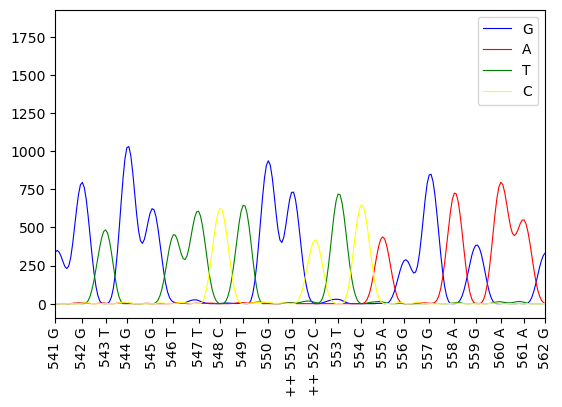

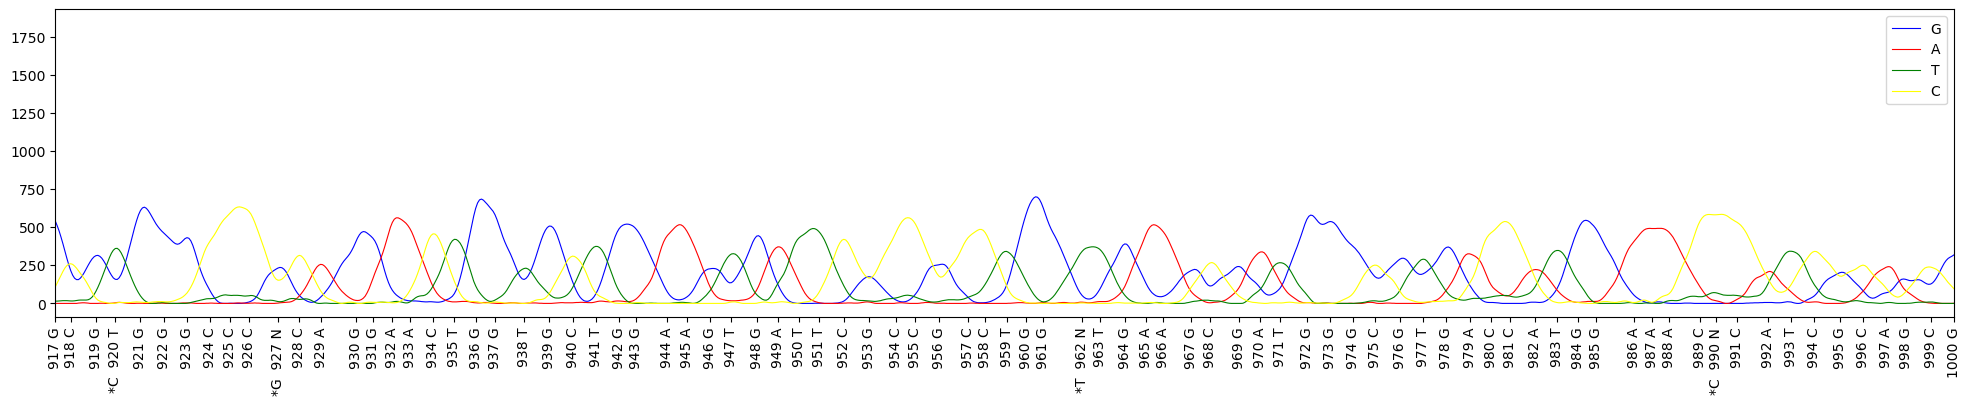

1_A2 1 fw


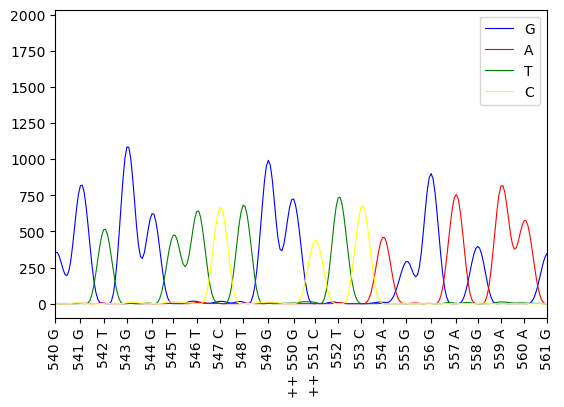

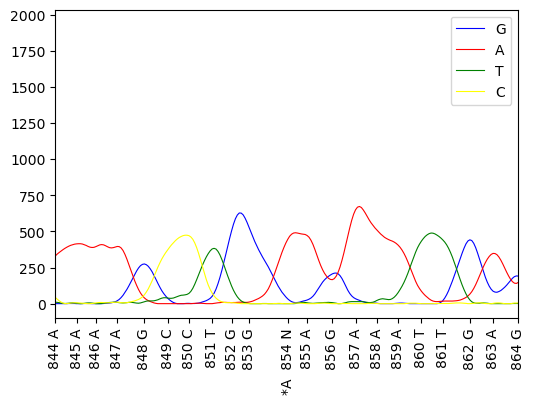

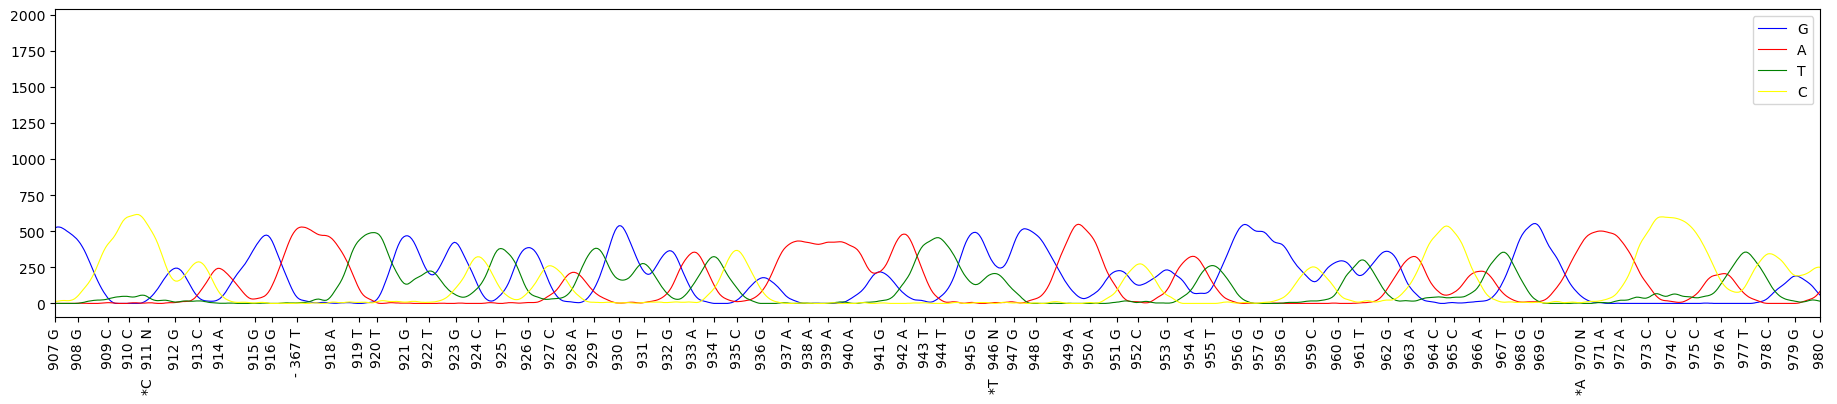

1_A3 1 fw


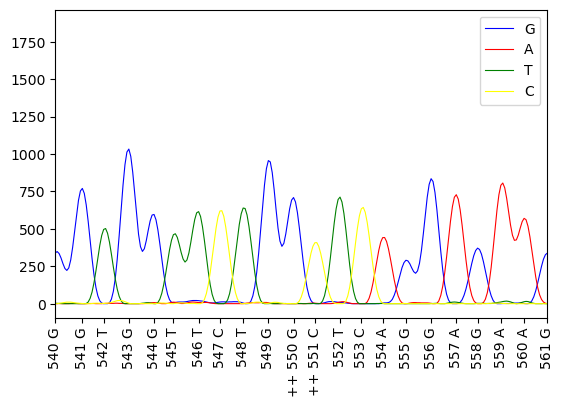

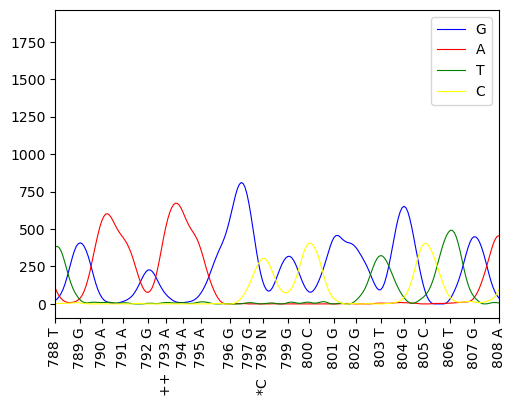

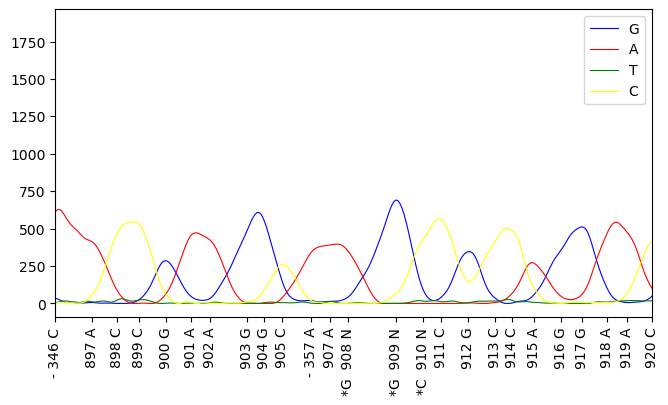

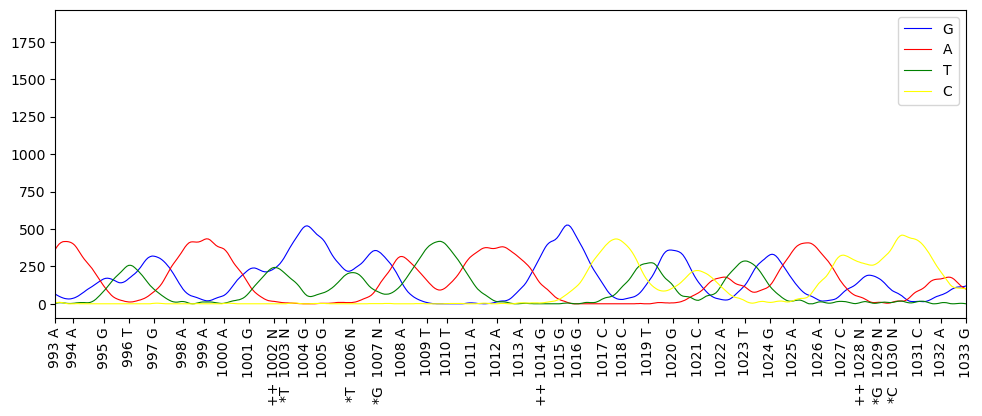

1_A4 1 fw


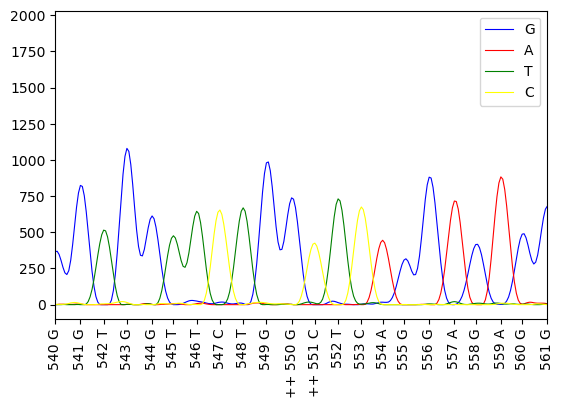

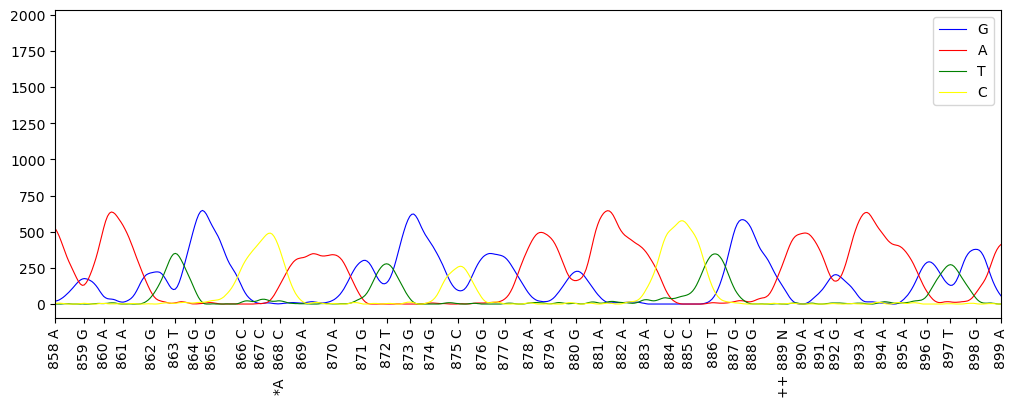

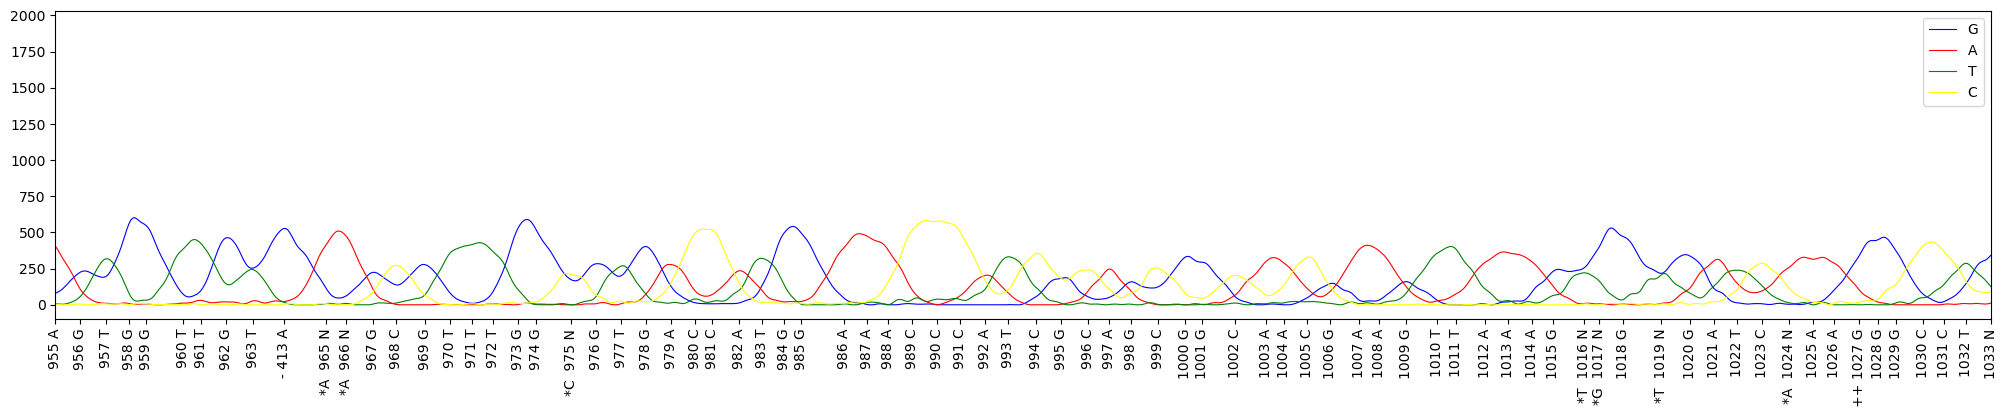

1_A5 1 fw


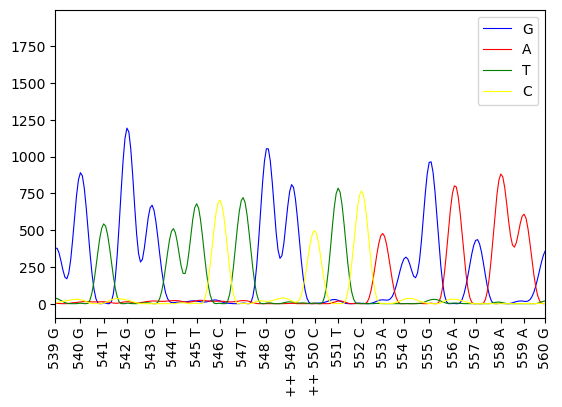

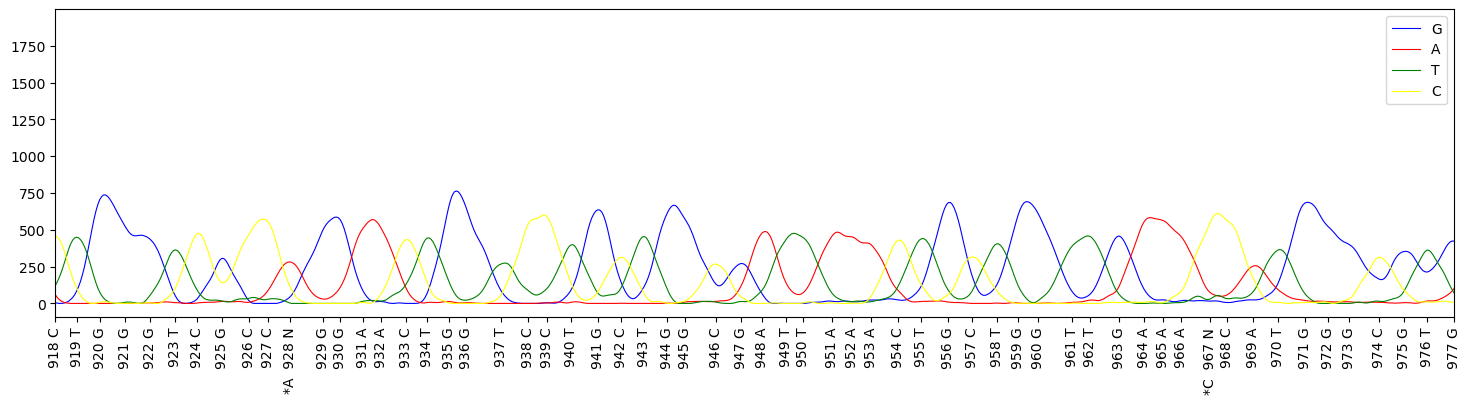

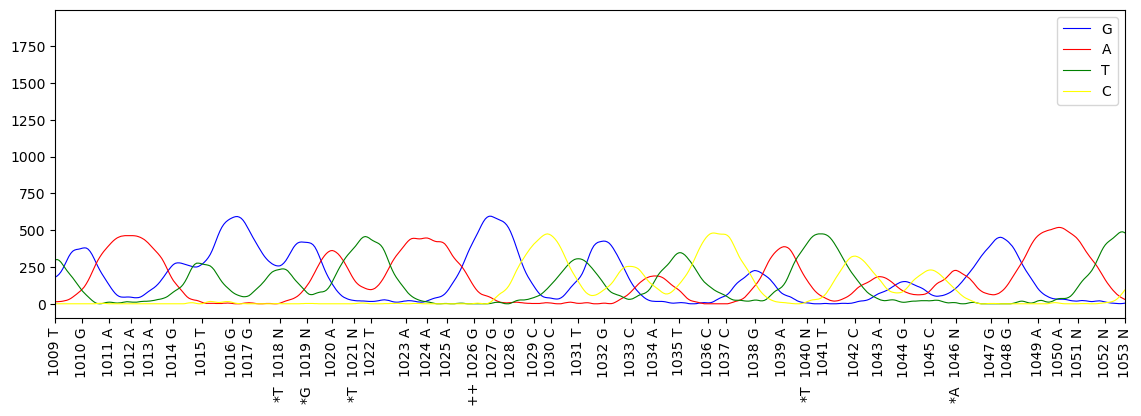

In [31]:
# plot 
qual = .95
find_mismatches_and_plot_close(map_df,qual)

## DataFrame describing overall quality

In [38]:
mini_df = map_df[['position', 'colony_num','direction','quality','mismatches', 'insertions', 'deletions']].copy()
pd.set_option('display.max_rows', None)
mini_df

,position,colony_num,direction,quality,mismatches,insertions,deletions
0,1_A1,1,fw,0.991304,"[{'pos_seq1': 370, 'pos_seq2': 920, 'base_seq1...","[{'seq2_range': (551, 553), 'seq1_pos': 3}]",[]
1,1_A2,1,fw,0.991071,"[{'pos_seq1': 304, 'pos_seq2': 854, 'base_seq1...","[{'seq2_range': (550, 552), 'seq1_pos': 3}, {'...","[{'seq1_range': (367, 368), 'seq2_pos': 917}]"
2,1_A3,1,fw,0.981250,"[{'pos_seq1': 248, 'pos_seq2': 798, 'base_seq1...","[{'seq2_range': (550, 552), 'seq1_pos': 3}, {'...","[{'seq1_range': (346, 347), 'seq2_pos': 896}, ..."
3,1_A4,1,fw,0.983333,"[{'pos_seq1': 318, 'pos_seq2': 868, 'base_seq1...","[{'seq2_range': (550, 552), 'seq1_pos': 3}, {'...","[{'seq1_range': (413, 414), 'seq2_pos': 964}]"
4,1_A5,1,fw,0.986000,"[{'pos_seq1': 379, 'pos_seq2': 928, 'base_seq1...","[{'seq2_range': (549, 551), 'seq1_pos': 3}, {'...",[]
5,1_A6,1,fw,0.991968,"[{'pos_seq1': 308, 'pos_seq2': 860, 'base_seq1...","[{'seq2_range': (553, 555), 'seq1_pos': 3}, {'...",[]
6,1_A7,1,fw,0.985169,"[{'pos_seq1': 371, 'pos_seq2': 919, 'base_seq1...","[{'seq2_range': (550, 552), 'seq1_pos': 3}, {'...","[{'seq1_range': (354, 355), 'seq2_pos': 903}, ..."
7,1_A8,1,fw,0.722222,"[{'pos_seq1': 4, 'pos_seq2': 13, 'base_seq1': ...","[{'seq2_range': (27, 31), 'seq1_pos': 18}, {'s...","[{'seq1_range': (23, 24), 'seq2_pos': 43}, {'s..."
8,1_A9,1,fw,0.995604,"[{'pos_seq1': 442, 'pos_seq2': 988, 'base_seq1...","[{'seq2_range': (549, 551), 'seq1_pos': 3}]","[{'seq1_range': (345, 346), 'seq2_pos': 893}, ..."
9,1_A10,1,fw,0.995402,"[{'pos_seq1': 356, 'pos_seq2': 904, 'base_seq1...","[{'seq2_range': (549, 551), 'seq1_pos': 3}]",[]


Free Space to graph things:
Change the variable to be whatever well position and colony you want to plot.
if the output graph looks tiny then double click it

fw
target            1 TG--TCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT
                  0 ||--||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           549 TGGCTCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT

target           59 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           609 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA

target          119 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           669 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA

target          179 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           729 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA

target          239 A



rv
target            1 TG--TCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT
                  0 ||--||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           333 TGGCTCAGGAGAAGAAGAAGAGAAAGAACGCGAGAAAGCGGTGAAAATTGCGTTTCTGAT

target           59 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           393 TCTGGAACTGGCGGTGCTGGCGGCGGAAGCGAAACGCCTGGGCTTTGAGAAAACCGCGAA

target          119 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           453 ACTGGCCGTGGAAGGCATGAAGAAACTGCTGGAATATGCGAAAGAAAAGCTGAGCGAAGA

target          179 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           513 ACTGGCGAAAATCCTGGAATATCTGGTGAAGAAAGCGCTGAAAGGCATTGAGAAAGGCGA

target          239 A



In [46]:
#Variables
position = '1_A1'
colony = 1
graph_start = 0
graph_stop = 'max' # can be 'max' or any bp number, based on your sequencing numbering, not your orf numbering

###########################################################################################################
for i, r in map_df.iterrows():
    if r.position == position and r.colony_num == colony:
        print(r.direction)
        print(r.alignments)
        _, bases_seq = annotate_base_and_get_bad_pos(r)
        plot_chromatograms(r.records, bases_seq = bases_seq, start = graph_start, stop = graph_stop)
        

In [3]:
reverse_complement('GGAGGATCCGAACAAAAG')

'CTTTTGTTCGGATCCTCC'